In [1]:
import matplotlib.pyplot as plt
import sympy as sym
import numpy as np
from IPython.display import display, Math, Latex
import pandas as pd

# Example of collecting data and outputting a table and a graph

In [2]:
# Example for collected data

# Measurement of RS_a, RS_b, RS_c
RSd_id = [r"$R_a$", r"$R_b$", r"$R_c$"]

RSd_2_a = 539 # R3 = 10 Ohm, Measurement: R2:539mm, R4: 1000-539mm
RSd_2_b = 526 # R3 = 200 Ohm, Measurement: R2:526mm, R4: 1000-526mm
RSd_2_c = 440 # R3 = 10k Ohm, Measurement: R2:440 bis 502mm, R4: 1000-539mm

RSd_2 = [RSd_2_a, RSd_2_b, RSd_2_c] # R2 in mm # Put all measurements in one vector

RSd_4 = [1000-R2 for R2 in RSd_2] # in Ohm, fuer alle Messungen gleich

RSd_3 = np.array([10, 200, 10000]) # in Ohm, variiert je nach zu messendem Widerstand, Reihenfolge: a, b, c
true_abc = [ 11.9, 217.8, 9983] # values for resistors under test assumed as true

# Create list with all data (given, measured and calculated) for each set and store in RSd_res
RSd_res = []
# row for table: R_x | R_2 | R_3 | R_4 | R_1 = R2/R4*R3 | Error R_1-true_abc | Error rel.
for i in range(len(RSd_id)):
    row = [ RSd_id[i], # Name of resistor under test
            RSd_2[i], # resistor 2
            RSd_4[i], # resistor 4
            RSd_3[i], # resistor 3
            RSd_2[i]/RSd_4[i]*RSd_3[i], # calculated value for resistor under test
            abs(RSd_2[i]/RSd_4[i]*RSd_3[i]-true_abc[i]), # deviation (error) from true value
            abs((RSd_2[i]/RSd_4[i]*RSd_3[i]-true_abc[i])/true_abc[i]) # relative error
            ]
    RSd_res.append(row) # put data point into result list

print(RSd_res)


[['$R_a$', 539, 461, np.int64(10), np.float64(11.691973969631238), np.float64(0.208026030368762), np.float64(0.01748117902258504)], ['$R_b$', 526, 474, np.int64(200), np.float64(221.9409282700422), np.float64(4.140928270042195), np.float64(0.019012526492388406)], ['$R_c$', 440, 560, np.int64(10000), np.float64(7857.142857142857), np.float64(2125.857142857143), np.float64(0.21294772541892648)]]


In [3]:
# Create table from data and calculation

# Create top row for naming colums
RSd_tab_id = [r'$R_X$', r'$R_2[\si{\mm}]$', r'$R_4[\si{\mm}]$', r'$R_3[\si{\ohm}]$', r"$R_X=\frac{R_2}{R_4}R_3[\si{\ohm}]$", r"\makecell{Fehler abs. [\si{\ohm}]\\$|R_X-R_{X}^{\text{wahr}}|$}", r"\makecell{Fehler rel.\\$\frac{|R_X-R_{X}^{\text{wahr}}|}{R_{X}^{\text{wahr}}}$}"] 
rows = RSd_res # Declare the result list from calculations as rows for table

df = pd.DataFrame(rows, columns=RSd_tab_id)

latex = df.to_latex(
    index=False,
    escape=False,
    column_format="c" * len(df.columns),
    float_format=lambda x: rf"\num{{{x:.4g}}}",
    # float_format="%.3f
)

table = rf"""
\begin{{table}}[H]
\centering
{latex}
\caption{{Messung der Widerständer mit der Schleifdrahtmessbrücke}}
\label{{tab:messungSchleifdraht}}
\end{{table}}
"""

with open("tableInTexFile.tex", "w", encoding="utf-8") as f:
    f.write(table)

print(table) # print table under this cell
display(df) # display table in pandas format for a better view (does not resemble rendered tex output!)


\begin{table}[H]
\centering
\begin{tabular}{ccccccc}
\toprule
$R_X$ & $R_2[\si{\mm}]$ & $R_4[\si{\mm}]$ & $R_3[\si{\ohm}]$ & $R_X=\frac{R_2}{R_4}R_3[\si{\ohm}]$ & \makecell{Fehler abs. [\si{\ohm}]\\$|R_X-R_{X}^{\text{wahr}}|$} & \makecell{Fehler rel.\\$\frac{|R_X-R_{X}^{\text{wahr}}|}{R_{X}^{\text{wahr}}}$} \\
\midrule
$R_a$ & 539 & 461 & 10 & \num{11.69} & \num{0.208} & \num{0.01748} \\
$R_b$ & 526 & 474 & 200 & \num{221.9} & \num{4.141} & \num{0.01901} \\
$R_c$ & 440 & 560 & 10000 & \num{7857} & \num{2126} & \num{0.2129} \\
\bottomrule
\end{tabular}

\caption{Messung der Widerständer mit der Schleifdrahtmessbrücke}
\label{tab:messungSchleifdraht}
\end{table}



,$R_X$,$R_2[\si{\mm}]$,$R_4[\si{\mm}]$,$R_3[\si{\ohm}]$,$R_X=\frac{R_2}{R_4}R_3[\si{\ohm}]$,\makecell{Fehler abs. [\si{\ohm}]\\$|R_X-R_{X}^{\text{wahr}}|$},\makecell{Fehler rel.\\$\frac{|R_X-R_{X}^{\text{wahr}}|}{R_{X}^{\text{wahr}}}$}
0,$R_a$,539,461,10,11.691974,0.208026,0.017481
1,$R_b$,526,474,200,221.940928,4.140928,0.019013
2,$R_c$,440,560,10000,7857.142857,2125.857143,0.212948


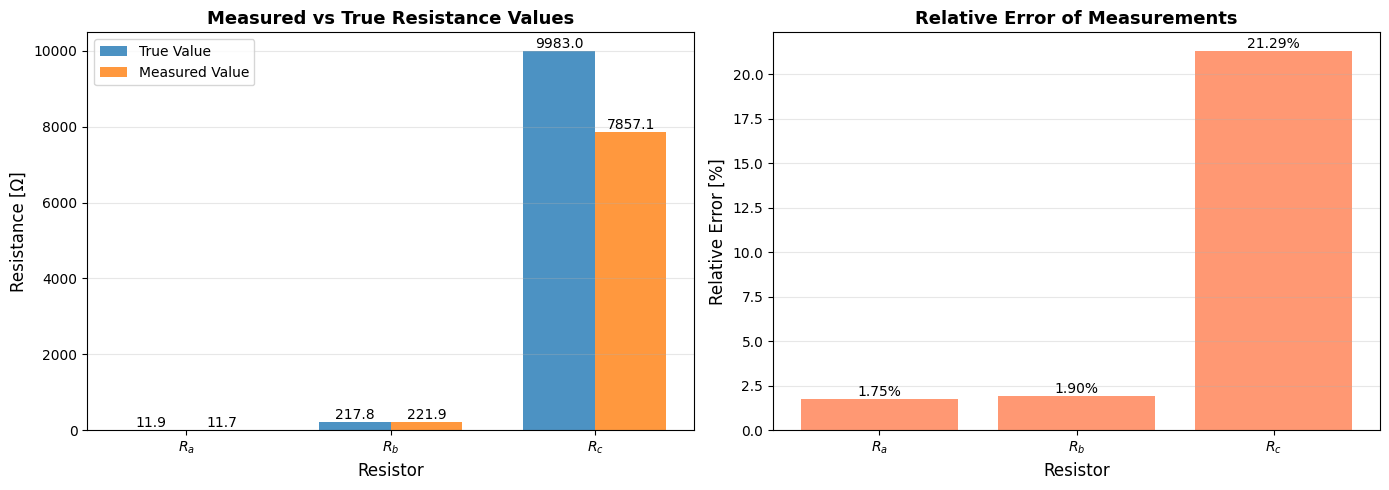


Summary of Results:
Mean relative error: 8.31%
Max relative error: 21.29%


In [4]:
# Create visualization of the measurement results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extract data for plotting
resistor_labels = ['$R_a$', '$R_b$', '$R_c$']
measured_values = [RSd_2[i]/RSd_4[i]*RSd_3[i] for i in range(len(RSd_id))]
absolute_errors = [abs(RSd_2[i]/RSd_4[i]*RSd_3[i]-true_abc[i]) for i in range(len(RSd_id))]
relative_errors = [abs((RSd_2[i]/RSd_4[i]*RSd_3[i]-true_abc[i])/true_abc[i])*100 for i in range(len(RSd_id))]

# Plot 1: Measured vs True values
x = np.arange(len(resistor_labels))
width = 0.35

bars1 = axes[0].bar(x - width/2, true_abc, width, label='True Value', alpha=0.8)
bars2 = axes[0].bar(x + width/2, measured_values, width, label='Measured Value', alpha=0.8)

axes[0].set_xlabel('Resistor', fontsize=12)
axes[0].set_ylabel('Resistance [Ω]', fontsize=12)
axes[0].set_title('Measured vs True Resistance Values', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(resistor_labels)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10)

# Plot 2: Relative Error
bars3 = axes[1].bar(resistor_labels, relative_errors, color='coral', alpha=0.8)
axes[1].set_xlabel('Resistor', fontsize=12)
axes[1].set_ylabel('Relative Error [%]', fontsize=12)
axes[1].set_title('Relative Error of Measurements', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars3:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nSummary of Results:")
print(f"Mean relative error: {np.mean(relative_errors):.2f}%")
print(f"Max relative error: {np.max(relative_errors):.2f}%")